In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, hypergeom
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure,
    precision_score, recall_score, f1_score, silhouette_score,
)

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False

sys.path.append('../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS         = 1
NUM_EPOCHS     = 500
VALIDATE_EVERY = 50
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 20
N_CLUSTERS     = 10
RESULTS_DIR    = "results/reproducibility"

SHERLOCK_KWARGS = {
    # "tau_end": 0.3,
    # # "tau_init": 1.5,
    # "cov_lambda": 1e-5,
    # "H_lambda": 1e-1,
    # "gate_row_repulsion_lambda": 1e-2,
    # "ce_lambda": 10,
    # "shift": "linear",
    "l0_lambda": 4,
    "debug": True,
    "n_epochs_l0_warmup": 200,
    # "lr": 1e-3,
    # "ntc_lambda": 1e-5,
    # "pert_lambda": 1,
}

os.makedirs(f"{RESULTS_DIR}/figures", exist_ok=True)
print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/reproducibility


## Data loading

In [4]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|██████████| 681/681 [00:08<00:00, 77.83it/s]


Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for cluster evaluation

In [5]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

# Flat table for merging (gene, pathway)
pathways_flat = pathway_df_indexed.reset_index()

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Cluster alignment helper

In [6]:
def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
    gene_embeddings=None,
    knn_k: int = 5,
    linear_probe_cv: int = 5,
):
    """Hungarian-match predicted clusters to ground-truth pathways.
    
    Embedding metrics (silhouette macro, kNN purity, linear probe) are
    computed via slk.tl.compute_embedding_metrics when gene_embeddings is provided.
    """
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col, how="inner", validate="one_to_one",
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    if min_pathway_size > 1:
        keep = df[pathway_col].value_counts()
        df = df[df[pathway_col].isin(keep[keep >= min_pathway_size].index)].copy()

    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    mapped   = np.array([mapping.get(cl) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy  = float(is_match.mean())
    precision = precision_score(y_true, mapped, average="macro", zero_division=0)
    recall    = recall_score(y_true, mapped, average="macro", zero_division=0)
    f1        = f1_score(y_true, mapped, average="macro", zero_division=0)
    ari       = adjusted_rand_score(y_true, y_pred)
    ami       = adjusted_mutual_info_score(y_true, y_pred)
    hom, com, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

    # Embedding-based metrics via shared helper
    sil = knn_pur = lin_probe = None
    if gene_embeddings is not None:
        emb = gene_embeddings.loc[df[gene_col].values].values
        emb_metrics = slk.tl.compute_embedding_metrics(
            emb, y_true, knn_k=knn_k, linear_probe_cv=linear_probe_cv
        )
        sil       = emb_metrics["silhouette"]
        knn_pur   = emb_metrics["knn_purity"]
        lin_probe = emb_metrics["linear_probe"]

    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        pur = (g[pathway_col] == majority).mean()
        rec_cl = (g[pathway_col] == majority).sum() / max((df[pathway_col] == majority).sum(), 1)
        purity_rows.append({"cluster": str(cl), "size": len(g),
                             "mapped_pathway": mapping.get(str(cl)), "purity": pur, "recall": rec_cl})
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    contingency = contingency_df.copy()
    row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    N_total = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes   = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            pval = hypergeom.sf(k - 1, N_total, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K,
                             "n": n, "N": N_total, "pval": float(pval)})
    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * max(len(enrich_df), 1), 1.0)
    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    df["mapped_pathway"] = mapped
    df["is_match"]       = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}),
        "mapping": mapping,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "ari": ari, "ami": ami,
        "homogeneity": hom, "completeness": com, "v_measure": vmeas,
        "silhouette": sil, "knn_purity": knn_pur, "linear_probe": lin_probe,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": row_norm,
        "contingency_col_norm": col_norm,
        "enrichment": enrich_df,
    }

## Reproducibility loop

Train Sherlock `N_RUNS` times independently. After each run extract:
- **W** — the (P × d) gate matrix from `model.gate(deterministic=True)`
- **rho_corr** — the (P × P) learned covariance correlation matrix
- **clusters** — hierarchical cut on the pathway-gene subset of rho_corr, then Hungarian-matched to pathways via `align_and_summarize`


Sherlock run 1/1
Training VAE on cuda …


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

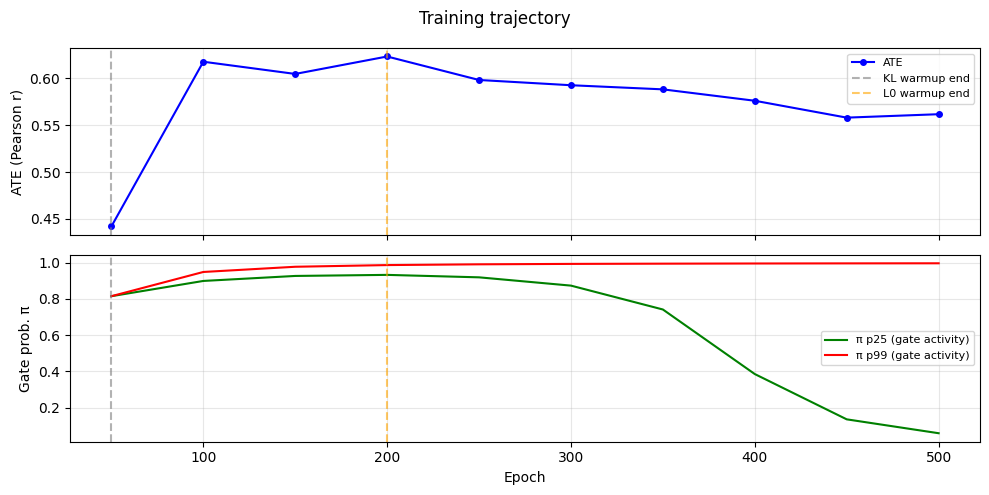

  accuracy=0.952  f1=0.928  ari=0.853  ami=0.915  sil=0.305  knn=0.917  lp=0.967  cf_ate_r=0.569

All runs complete.


In [7]:
run_results     = []
per_run_metrics = []

for run in range(N_RUNS):
    print(f"\n{'='*50}\nSherlock run {run + 1}/{N_RUNS}\n{'='*50}")

    out = slk.tl.run(
        data,
        model="vae",
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        device=DEVICE,
        latent_dim=LATENT_DIM,
        patience=PATIENCE,
        validate_every=VALIDATE_EVERY,
        seed=run,
        # debug=True,
        **SHERLOCK_KWARGS,
    )
    model = out['model']

    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    results = data.uns['results']

    # Gate matrix W: (P, d)
    W = model.gate(deterministic=True).detach().cpu().numpy()

    # Learned covariance correlation: (P, P)
    #NOTE using z corr to be comparable to other methods
    rho_corr  = np.asarray(results['z_corr'],  dtype=float)
    rho_perts = np.asarray(results['z_perts'])

    # Pathway-gene subset and clustering
    pert_to_idx = {name: i for i, name in enumerate(rho_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = rho_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    raw_clusters = slk.tl.cluster_rho(
        data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False
    )

    # Gene embeddings from rho_embed for embedding-based metrics
    rho_embed = results.get('rho_embed')
    gene_embeddings = None
    if rho_embed is not None:
        gene_embeddings = pd.DataFrame(
            np.asarray(rho_embed)[gene_ids],
            index=valid_genes,
        )

    # Hungarian-match cluster labels to pathway names
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': raw_clusters})
    align_out   = align_and_summarize(clusters_df, pathways_flat, gene_embeddings=gene_embeddings)

    merged = align_out['merged'].set_index('gene')
    mapped_pathway = np.array(
        [merged.loc[g, 'mapped_pathway'] if g in merged.index else None
         for g in valid_genes],
        dtype=object,
    )

    # Counterfactual ATE
    ate_metrics = slk.tl.compute_cf_ate_metrics(model, data, treat_effect_adata)

    run_results.append({
        'run':            run,
        'W':              W,
        'rho_corr':       rho_corr,
        'rho_perts':      rho_perts,
        'valid_genes':    valid_genes,
        'raw_clusters':   raw_clusters,
        'mapped_pathway': mapped_pathway,
        'align_out':      align_out,
    })

    m = align_out
    per_run_metrics.append({
        'run':              run + 1,
        'accuracy':         m['accuracy'],
        'precision':        m['precision'],
        'recall':           m['recall'],
        'f1':               m['f1'],
        'ari':              m['ari'],
        'ami':              m['ami'],
        'homogeneity':      m['homogeneity'],
        'completeness':     m['completeness'],
        'v_measure':        m['v_measure'],
        'silhouette':       m['silhouette'],
        'knn_purity':       m['knn_purity'],
        'linear_probe':     m['linear_probe'],
        'cf_ate_pearson_r': ate_metrics['cf_ate_pearson_r'],
    })
    sil_str = f"  sil={m['silhouette']:.3f}" if m['silhouette'] is not None else ""
    knn_str = f"  knn={m['knn_purity']:.3f}" if m['knn_purity'] is not None else ""
    lp_str  = f"  lp={m['linear_probe']:.3f}" if m['linear_probe'] is not None else ""
    ate_val = ate_metrics['cf_ate_pearson_r']
    ate_str = f"  cf_ate_r={ate_val:.3f}" if np.isfinite(ate_val) else "  cf_ate_r=N/A"
    print(f"  accuracy={m['accuracy']:.3f}  f1={m['f1']:.3f}  ari={m['ari']:.3f}  ami={m['ami']:.3f}{sil_str}{knn_str}{lp_str}{ate_str}")

print("\nAll runs complete.")

In [8]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

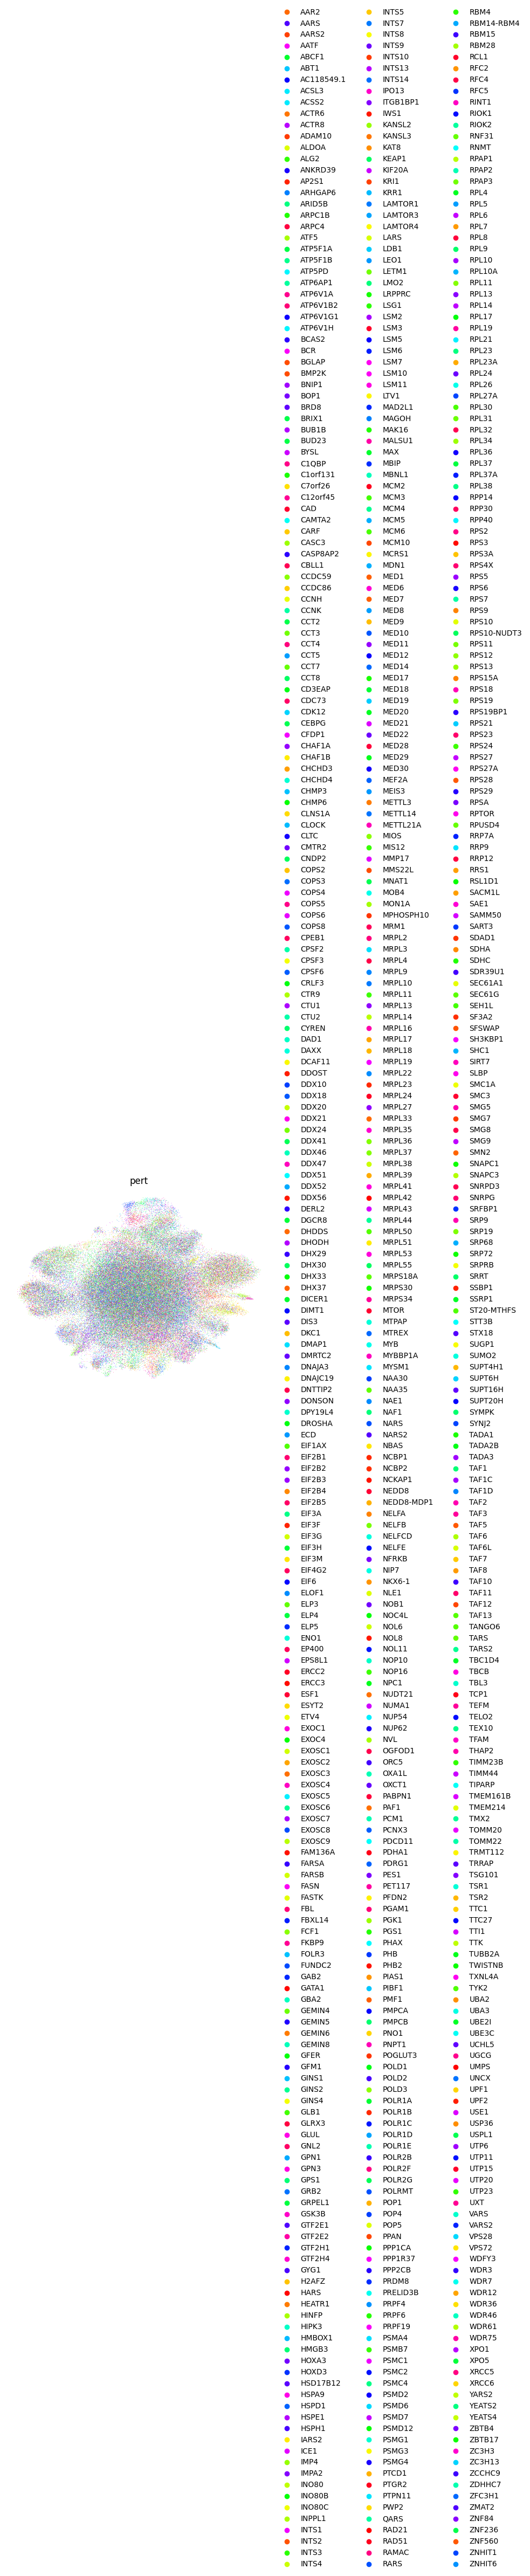

In [9]:
import scanpy as sc

p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [14]:
z_corr = data.uns['results'].get('z_corr')
rho_corr = data.uns['results'].get('rho_corr')

from scipy.stats import pearsonr, spearmanr

pearson = pearsonr(z_corr.flatten(), rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())

print(f"Spearman ρ = {spearman[0]:.3f}  (p = {spearman[1]:.1e})")
print(f" Pearson  r = {pearson[0]:.3f}  (p = {pearson[1]:.1e})") 

Spearman ρ = 0.637  (p = 0.0e+00)
 Pearson  r = 0.651  (p = 0.0e+00)


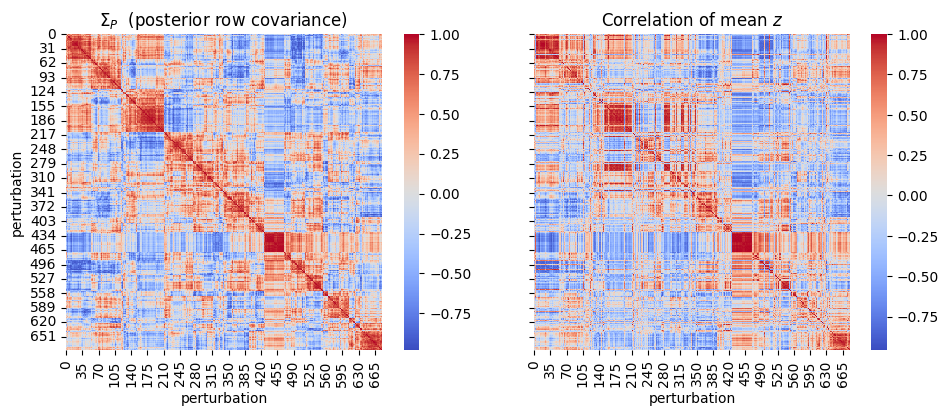

In [15]:
slk.pl.plot_zcorr(data)

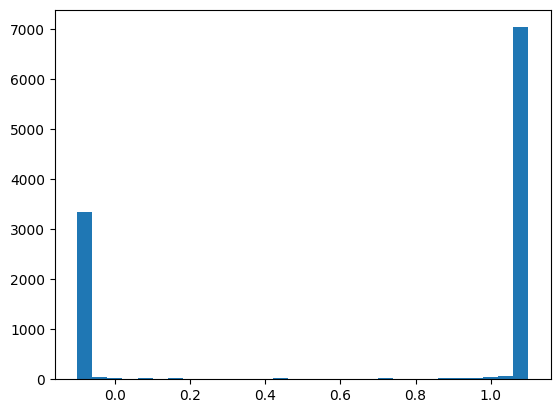

In [16]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

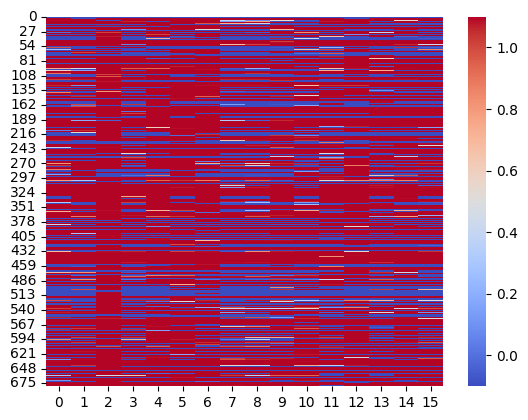

In [17]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [18]:
perturbations = set(np.unique(data.obs[slk.configs.get_config('pert_key')].values))
print("Perturbations:", len(perturbations))

pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
sum([len(pathways[i]) for i in range(len(pathways))])
print("Pathways:", len(pathways))

overlap = any(len(set(pathways[i]) & set(pathways[j])) > 0 for i in range(len(pathways)) for j in range(i + 1, len(pathways)))
print("Overlap exists between pathways:" if overlap else "No overlap between pathways.")

Perturbations: 682
Pathways: 8
No overlap between pathways.


In [19]:
p_key = slk.configs.get_config('pert_key')

dataset = slk.tl.PerturbMatchingDataset(data)
n_perts    = len(dataset.perturbation_dict)
latent_dim = data.obsm['z'].shape[1]

z_bar = np.zeros((n_perts, latent_dim))
for pert, pidx in dataset.perturbation_dict.items():
    mask = data.obs[p_key] == pert
    if mask.any():
        z_bar[pidx] = data.obsm['z'][mask].mean(0)

C = np.corrcoef(z_bar)

In [20]:
# C = data.uns['results']['rho_corr']

#Specific subsetting for replogle. Otherwise just use C directly
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]
dataset = slk.tl.PerturbMatchingDataset(data)
gene_ids = [dataset.perturbation_dict[g] for g in all_genes]
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

In [34]:
groups = slk.tl.cluster_rho(data, t=10, rho_corr=cov_subset, show=True, criterion='maxclust')

show=True is only supported for criterion='distance'. Ignoring.


In [35]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)

from collections import Counter

# Flatten all genes from all pathways
#all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

# Count how many times each gene appears
gene_counts = Counter(all_genes)

# Find genes that appear in more than one pathway
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]

if shared_genes:
    print(f"⚠️ {len(shared_genes)} genes are shared across pathways:")
    print(shared_genes[:20])  # show first 20 for inspection
else:
    print("✅ Each gene appears in exactly one pathway.")


#pert df
pathway_genes = np.concatenate([i for i in list(data.uns['pathways'].values())])
pathway_genes = pathway_genes[pathway_genes != 'LSM5']
print(len(pathway_genes))
print(len(all_genes))
perts = pd.DataFrame(groups, index=all_genes, columns=['cluster'])
perts = perts.loc[pathway_genes]

#pathway df
gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes if gene != 'LSM5'
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient="index", columns=["cluster"])


perts = perts.drop(shared_genes, errors="ignore")
pathway_df = pathway_df.drop(shared_genes, errors="ignore")

print("After removal:")
print("perts size     :", perts.shape)
print("pathway_df size:", pathway_df.shape)

pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']

perts_aligned = perts.loc[pathway_df.index]

perts_aligned['gene'] = perts_aligned.index.copy()

✅ Each gene appears in exactly one pathway.
335
335
After removal:
perts size     : (335, 1)
pathway_df size: (335, 1)


In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure, silhouette_score,
    precision_score, recall_score, f1_score,
)
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
from scipy.stats import hypergeom

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False


def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
    gene_embeddings: pd.DataFrame | None = None,  # index=gene, cols=latent dims
):
    # 1) Merge on gene
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col,
        how="inner",
        validate="one_to_one"
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    # Optional: filter tiny pathways to stabilize Hungarian/enrichment
    if min_pathway_size > 1:
        keep_path = df[pathway_col].value_counts()
        keep_path = keep_path[keep_path >= min_pathway_size].index
        df = df[df[pathway_col].isin(keep_path)].copy()

    # Cast to string for safe indexing
    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    # 2) Contingency (rows=pathways, cols=clusters)
    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    # 3) Hungarian alignment to maximize correct assignments (sum of diagonal)
    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)  # maximize
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    # Assign any unmapped clusters to their majority pathway (fallback)
    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    # 4) Remap clusters → pathways and compute metrics
    mapped = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy = float(is_match.mean())

    # Global F1 / precision / recall (macro-averaged over pathways)
    precision = precision_score(y_true, mapped, average="macro", zero_division=0)
    recall    = recall_score(y_true, mapped, average="macro", zero_division=0)
    f1        = f1_score(y_true, mapped, average="macro", zero_division=0)

    # Label-based external clustering metrics
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y_true, y_pred)

    # Silhouette score (requires embeddings)
    sil = None
    if gene_embeddings is not None:
        genes_in_df = df[gene_col].values
        emb = gene_embeddings.loc[genes_in_df].values
        sil = silhouette_score(emb, mapped, metric='euclidean')

    # 5) Per-cluster purity & recall
    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        purity = (g[pathway_col] == majority).mean()
        pathway_total = (df[pathway_col] == majority).sum()
        recall_cl = (g[pathway_col] == majority).sum() / pathway_total
        purity_rows.append({
            "cluster": str(cl),
            "size": len(g),
            "mapped_pathway": mapping.get(str(cl), None),
            "purity": purity,
            "recall": recall_cl,
        })
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    # 6) Normalized contingency for plotting
    contingency = contingency_df.copy()
    contingency_row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    contingency_col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    # 7) Pathway↔cluster enrichment (hypergeometric with FDR)
    N = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            pval = hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K, "n": n, "N": N, "pval": float(pval)})

    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        m = max(len(enrich_df), 1)
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * m, 1.0)

    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    # 8) Attach mapped labels into the merged table
    df["mapped_pathway"] = mapped
    df["is_match"] = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}
        ),
        "mapping": mapping,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "ari": ari,
        "ami": ami,
        "homogeneity": homogeneity,
        "completeness": completeness,
        "v_measure": v_measure,
        "silhouette": sil,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": contingency_row_norm,
        "contingency_col_norm": contingency_col_norm,
        "enrichment": enrich_df,
    }

In [37]:
gene_embeddings = pd.DataFrame(
    z_bar[gene_ids],
    index=all_genes,
)

results = align_and_summarize(
    clusters_df=perts_aligned,          # gene↦cluster from covariance HC
    pathways_df=pathway_df,             # gene↦pathway ground truth
    gene_col="gene",
    cluster_col="cluster",
    pathway_col="pathway",
    min_pathway_size=1,                 # optional: filter tiny pathways
    gene_embeddings=gene_embeddings,
)

print("Best cluster→pathway mapping:")
for cl, pw in results["mapping"].items():
    print(f"  {cl} → {pw}")

print(f"\nGlobal alignment accuracy: {results['accuracy']:.3f}")
print(f"Precision: {results['precision']:.3f} | Recall: {results['recall']:.3f} | F1: {results['f1']:.3f}")
print(f"ARI: {results['ari']:.3f} | AMI: {results['ami']:.3f}")
print(f"Homogeneity: {results['homogeneity']:.3f} | Completeness: {results['completeness']:.3f} | V-measure: {results['v_measure']:.3f}")
print(f"Silhouette:  {results['silhouette']:.3f}")

print("\nPer-cluster purity:")
print(results["purity_df"])

Best cluster→pathway mapping:
  3 → EXOSOME
  8 → MEDIATOR_COMPLEX
  7 → MT_PROTEIN_TRANSLOCATION
  10 → NUCLEOTIDE_EXCISION_REPAIR
  6 → S39_RIBOSOMAL_UNIT
  5 → S40_RIBOSOMAL_UNIT
  2 → S60_RIBOSOMAL_UNIT
  9 → SPLICEOSOME
  1 → S60_RIBOSOMAL_UNIT
  4 → S40_RIBOSOMAL_UNIT

Global alignment accuracy: 0.952
Precision: 0.948 | Recall: 0.939 | F1: 0.928
ARI: 0.853 | AMI: 0.915
Homogeneity: 0.957 | Completeness: 0.884 | V-measure: 0.920
Silhouette:  0.398

Per-cluster purity:
         size              mapped_pathway    purity    recall
cluster                                                      
1           4          S60_RIBOSOMAL_UNIT  0.750000  0.056604
10         38  NUCLEOTIDE_EXCISION_REPAIR  0.605263  1.000000
2          50          S60_RIBOSOMAL_UNIT  1.000000  0.943396
3          20                     EXOSOME  1.000000  1.000000
4          16          S40_RIBOSOMAL_UNIT  1.000000  0.164948
5          81          S40_RIBOSOMAL_UNIT  1.000000  0.835052
6          43          S39

In [31]:
results_df = results['merged']
clustered_genes = results_df["gene"].unique()

z_sub = sub[sub.obs["pert"].isin(clustered_genes)].copy()
sc.pp.neighbors(z_sub, use_rep='z')
sc.tl.umap(z_sub)

/var/tmp/ipykernel_3003089/579651866.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works


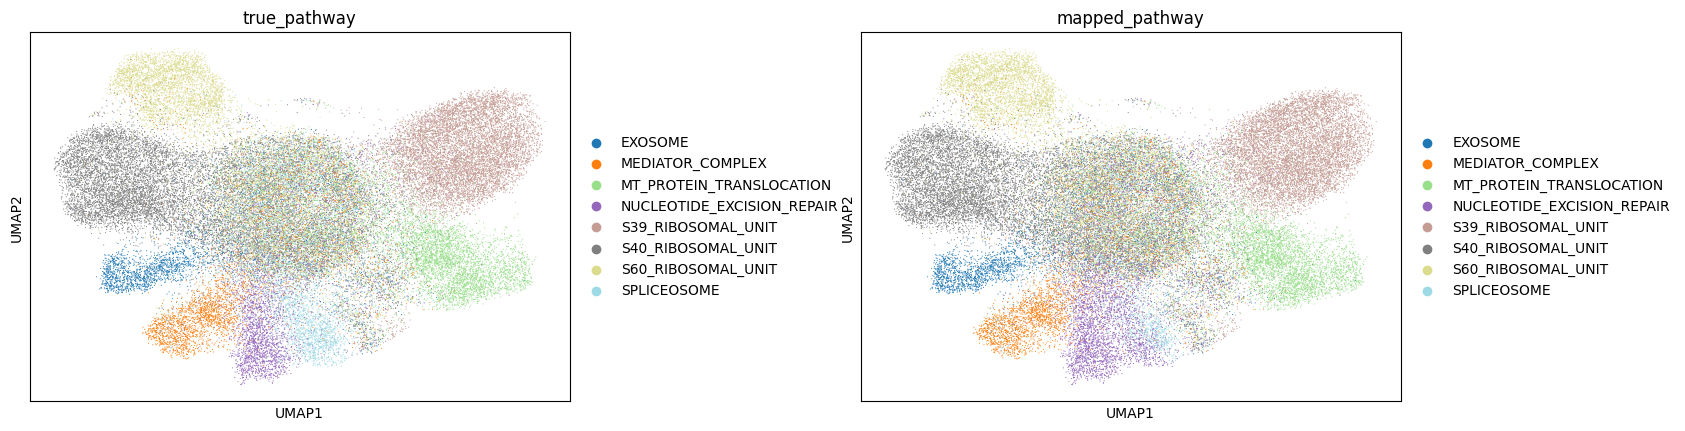

In [38]:
import numpy as np
import pandas as pd
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt

gene_to_true   = dict(zip(results_df["gene"], results_df["pathway"]))
gene_to_mapped = dict(zip(results_df["gene"], results_df["mapped_pathway"]))

z_sub.obs["true_pathway"]   = z_sub.obs["pert"].map(gene_to_true)
z_sub.obs["mapped_pathway"] = z_sub.obs["pert"].map(gene_to_mapped)

# Drop NA mapped rows
z_sub = z_sub[z_sub.obs["mapped_pathway"].notna() & (z_sub.obs["mapped_pathway"] != "NA")].copy()

# --- NEW: enforce identical palettes for both columns ---
# 1) Make both columns categorical with the SAME category set & order
true_vals   = pd.Index(z_sub.obs["true_pathway"].dropna().unique().astype(str))
mapped_vals = pd.Index(z_sub.obs["mapped_pathway"].dropna().unique().astype(str))
all_cats = pd.Index(np.unique(true_vals.union(mapped_vals)))  # sorted union

cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs["true_pathway"]   = z_sub.obs["true_pathway"].astype("string").astype(cat_dtype)
z_sub.obs["mapped_pathway"] = z_sub.obs["mapped_pathway"].astype("string").astype(cat_dtype)

# 2) Build a single color palette over all categories
cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}

# 3) Write per-column color lists in each column's category order
true_order   = list(z_sub.obs["true_pathway"].cat.categories)
mapped_order = list(z_sub.obs["mapped_pathway"].cat.categories)

z_sub.uns["true_pathway_colors"]   = [shared_palette[c] for c in true_order]
z_sub.uns["mapped_pathway_colors"] = [shared_palette[c] for c in mapped_order]

# --- Plot (colors now matched across panels) ---
import scanpy as sc
sc.pl.umap(
    z_sub,
    color=["true_pathway", "mapped_pathway"],
    wspace=0.4,
)

## Per-run clustering metrics

In [8]:
metrics_df = pd.DataFrame(per_run_metrics).set_index('run')
print(metrics_df.round(4).to_string())
print("\nMean ± Std:")
for col in metrics_df.columns:
    v = pd.to_numeric(metrics_df[col], errors='coerce').dropna().values
    if len(v) > 0:
        print(f"  {col:15s}: {np.mean(v):.4f} ± {np.std(v):.4f}")
    else:
        print(f"  {col:15s}: N/A")

     accuracy  precision  recall      f1     ari     ami  homogeneity  completeness  v_measure  silhouette  knn_purity  linear_probe  cf_ate_pearson_r
run                                                                                                                                                   
1      0.9881      0.995  0.9906  0.9926  0.9456  0.9538       0.9851        0.9289     0.9562      0.2716      0.8842        0.9582            0.5259

Mean ± Std:
  accuracy       : 0.9881 ± 0.0000
  precision      : 0.9950 ± 0.0000
  recall         : 0.9906 ± 0.0000
  f1             : 0.9926 ± 0.0000
  ari            : 0.9456 ± 0.0000
  ami            : 0.9538 ± 0.0000
  homogeneity    : 0.9851 ± 0.0000
  completeness   : 0.9289 ± 0.0000
  v_measure      : 0.9562 ± 0.0000
  silhouette     : 0.2716 ± 0.0000
  knn_purity     : 0.8842 ± 0.0000
  linear_probe   : 0.9582 ± 0.0000
  cf_ate_pearson_r: 0.5259 ± 0.0000


## Pairwise similarity metrics

For each pair of runs compute:

1. **W correlation** — Pearson r between upper triangles of `W @ Wᵀ` (co-activation matrices, invariant to latent-dim permutation).

2. **Covariance correlation** — Pearson r between upper triangles of `rho_corr`.

3. **Cluster Jaccard (defined)** — Jaccard co-membership similarity using the raw hierarchical cluster integer labels (permutation-invariant by construction).

4. **Cluster Jaccard (matched)** — Same co-membership Jaccard but using the **Hungarian-matched** pathway labels, so identical names mean the same pathway in both runs.
   $$J = \frac{|\{(i,j): \text{same label in both runs}\}|}{|\{(i,j): \text{same label in at least one run}\}|}$$

In [9]:
def _jaccard_comembership(labels_i, labels_j):
    """Jaccard similarity of pairwise co-membership indicators."""
    n = len(labels_i)
    same_i = labels_i[:, None] == labels_i[None, :]
    same_j = labels_j[:, None] == labels_j[None, :]
    triu   = np.triu_indices(n, k=1)
    a, b   = same_i[triu], same_j[triu]
    union  = int((a | b).sum())
    return int((a & b).sum()) / union if union > 0 else np.nan


pairs = list(combinations(range(N_RUNS), 2))

w_corrs           = []
cov_corrs         = []
jaccard_defined   = []
jaccard_matched   = []

for i, j in pairs:
    ri, rj = run_results[i], run_results[j]

    # --- W co-activation correlation ---
    Wi, Wj = ri['W'], rj['W']
    Ci = Wi @ Wi.T
    Cj = Wj @ Wj.T
    triu = np.triu_indices(Ci.shape[0], k=1)
    r_W, _ = pearsonr(Ci[triu], Cj[triu])
    w_corrs.append(r_W)

    # --- rho_corr correlation ---
    rho_i, rho_j = ri['rho_corr'], rj['rho_corr']
    triu_rho = np.triu_indices(rho_i.shape[0], k=1)
    fi, fj   = rho_i[triu_rho], rho_j[triu_rho]
    valid    = np.isfinite(fi) & np.isfinite(fj)
    r_cov, _ = pearsonr(fi[valid], fj[valid])
    cov_corrs.append(r_cov)

    # --- Jaccard (defined): raw hierarchical cluster integers ---
    cl_i = ri['raw_clusters'].astype(object)
    cl_j = rj['raw_clusters'].astype(object)
    jaccard_defined.append(_jaccard_comembership(cl_i, cl_j))

    # --- Jaccard (matched): Hungarian-matched pathway labels ---
    genes_i = ri['valid_genes']
    genes_j = rj['valid_genes']
    common  = [g for g in genes_i if g in set(genes_j)]

    gi_idx = {g: k for k, g in enumerate(genes_i)}
    gj_idx = {g: k for k, g in enumerate(genes_j)}

    mp_i = np.array([ri['mapped_pathway'][gi_idx[g]] for g in common], dtype=object)
    mp_j = np.array([rj['mapped_pathway'][gj_idx[g]] for g in common], dtype=object)

    both_valid = np.array([a is not None and b is not None for a, b in zip(mp_i, mp_j)])
    mp_i = mp_i[both_valid]
    mp_j = mp_j[both_valid]
    jaccard_matched.append(_jaccard_comembership(mp_i, mp_j))

pair_labels = [f"run{i+1}–run{j+1}" for i, j in pairs]

summary_df = pd.DataFrame({
    'pair':               pair_labels,
    'W_coact_pearson_r':  w_corrs,
    'rho_corr_pearson_r': cov_corrs,
    'cluster_jaccard_defined': jaccard_defined,
    'cluster_jaccard_matched': jaccard_matched,
})

print(summary_df.to_string(index=False))
print("\nMean ± Std across pairs:")
for col in ['W_coact_pearson_r', 'rho_corr_pearson_r', 'cluster_jaccard_defined', 'cluster_jaccard_matched']:
    vals = summary_df[col].dropna().values
    print(f"  {col:30s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

IndexError: list index out of range

## Visualisation

In [ ]:
ate_values = pd.to_numeric(metrics_df['cf_ate_pearson_r'], errors='coerce').dropna().tolist()

metric_info = [
    (w_corrs,         'W co-activation\nPearson r',   'Pearson r'),
    (cov_corrs,       'rho_corr\nPearson r',           'Pearson r'),
    (jaccard_defined, 'Cluster Jaccard\n(defined)',    'Jaccard'),
    (jaccard_matched, 'Cluster Jaccard\n(matched)',    'Jaccard'),
    (ate_values,      'CF ATE\nPearson r',             'Pearson r'),
]

fig, axes = plt.subplots(1, 5, figsize=(19, 4))

for ax, (values, title, ylabel) in zip(axes, metric_info):
    clean = [v for v in values if np.isfinite(v)]
    ax.boxplot(clean, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
    ax.scatter([1] * len(clean), clean, color='steelblue', s=50, zorder=3, alpha=0.85)
    m = np.mean(clean)
    ax.axhline(m, color='tomato', linestyle='--', linewidth=1.5, label=f'mean = {m:.3f}')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_xlim(0.5, 1.5)
    ax.legend(fontsize=9)

fig.suptitle(f'Sherlock reproducibility across {N_RUNS} independent runs (Replogle)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_boxplots.png', bbox_inches='tight')
plt.show()

## Pairwise heatmaps

Show the full N×N grid of pairwise similarities as heatmaps.

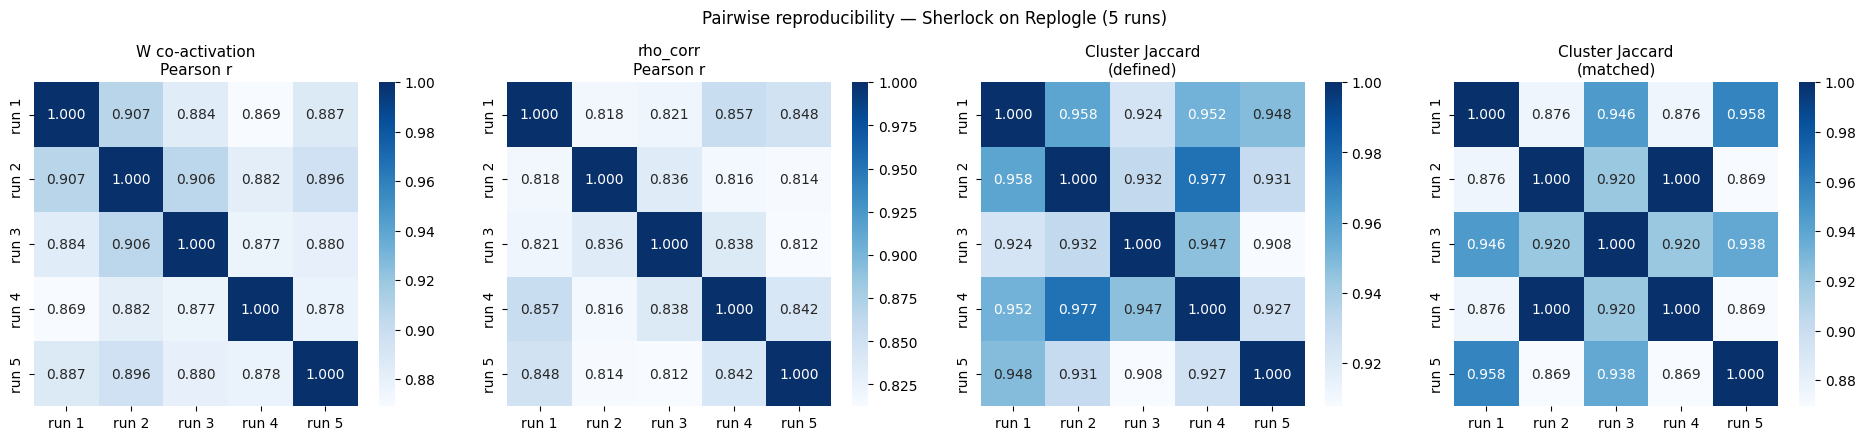

In [ ]:
def to_matrix(values, n_runs, pairs):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, 1.0)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

W_mat  = to_matrix(w_corrs,         N_RUNS, pairs)
C_mat  = to_matrix(cov_corrs,       N_RUNS, pairs)
Jd_mat = to_matrix(jaccard_defined, N_RUNS, pairs)
Jm_mat = to_matrix(jaccard_matched, N_RUNS, pairs)

run_labels = [f"run {k+1}" for k in range(N_RUNS)]

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

for ax, mat, title in zip(
    axes,
    [W_mat, C_mat, Jd_mat, Jm_mat],
    ['W co-activation\nPearson r', 'rho_corr\nPearson r',
     'Cluster Jaccard\n(defined)', 'Cluster Jaccard\n(matched)'],
):
    off_diag = mat[~np.eye(N_RUNS, dtype=bool)]
    vmin = np.nanmin(off_diag)
    sns.heatmap(
        mat, ax=ax, annot=True, fmt='.3f',
        vmin=vmin, vmax=1.0, cmap='Blues',
        xticklabels=run_labels, yticklabels=run_labels, square=True,
    )
    ax.set_title(title, fontsize=11)

plt.suptitle(f'Pairwise reproducibility — Sherlock on Replogle ({N_RUNS} runs)', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_heatmaps.png', bbox_inches='tight')
plt.show()